# UTS Data Mining 2 Soal Text: Clustering


### Notebook ini disusun biar gampang copas dari PPT
PPT: **"Text Mining - Clustering"** (Dr. Maryamah, 53 slide). Nomor slide = nomor halaman PDF-nya.
Kode di PPT berupa **gambar** (ga bisa di-copy), jadi diketik ulang. Tiap cell ditulis **sama persis kayak di slide**, termasuk import-nya (import ditaruh di cell tempat dia dipakai, sama kayak di slide).

Penanda di kode:
| Penanda | Artinya |
|---|---|
| `# slide X` | diketik ulang dari slide X, **tinggal liat PPT** |
| `# [HAFALIN]` | **ga ada di PPT**, harus hafal (udah dibikin sependek mungkin) |
| `# [GANTI]` | placeholder: wajib diganti kalau datasetnya beda |
| `# [OPSIONAL]` | cuma kalau datanya punya kolom label/kategori; kalau ga ada, hapus |
| `# [FIX]` | kode di slide salah, ini yang udah dibenerin |

### Peta: mana dari PPT, mana harus hafal

| Langkah | Sumber | Section |
|---|---|---|
| Load CSV + cek data | **HAFALIN** | 1 |
| Plot deskriptif | **HAFALIN** | 2 |
| Cleaning (lower + regex) | slide 11 | 3 |
| Tokenisasi | slide 13 | 3 |
| Stopword | slide 15 | 3 |
| Stemming | slide 16 | 3 |
| Fungsi `preprocess` + `apply` (penyambung slide 11–16) | **HAFALIN** (cuma `def`, `return`, `apply`) | 3 |
| Wordcloud | slide 21 | 3 & 8 |
| TF-IDF | slide 45 | 4 |
| Elbow + silhouette | **HAFALIN** | 5 |
| KMeans | slide 46 | 6 |
| Skor evaluasi | **HAFALIN** | 6 |
| PCA + masukin ke df | slide 48, 49 | 7 |
| Scatter plot | slide 51 | 7 |
| Top keywords + nama cluster | slide 50 | 8 |
| Crosstab ke label | **HAFALIN** | 8 |

**Intinya yang wajib hafal cuma 5 hal:** load CSV, fungsi penyambung preprocessing, loop elbow/silhouette, 2 baris skor evaluasi, sama crosstab. Sisanya liat PPT.

### Alur (diagram slide 37)
CSV → kenalan sama data → **preprocessing** → **TF-IDF** → tentukan k → **KMeans** → evaluasi → **PCA** buat plot → insight tiap cluster → kesimpulan.

## 1. Load data & kenalan sama data `[HAFALIN]`

Di PPT (slide 43) dosen pakai dataset bawaan `fetch_20newsgroups`, jadi **load CSV ga ada di PPT**.

Trik biar sisanya gampang copas: **kolom teks di-rename jadi `corpus`**, soalnya di slide 44 kolom teksnya namanya `corpus`. Jadi semua kode setelah ini bisa ditulis sama persis kayak slide.

Pas pertama kali dapet data, yang dicek:
1. **`shape`**: berapa baris (= jumlah dokumen) dan kolom.
2. **`head()`**: kolom mana yang isinya **teks** → itu yang di-cluster.
3. **`info()` / `isna()`**: ada teks kosong ga? Kalau ada dibuang.
4. **`nunique()`**: kolom yang nilai uniknya sedikit (mis. 2 atau 4) = kolom **label/kategori**. Label **ga dipakai** buat clustering, karena clustering itu *unsupervised* (slide 3–4): modelnya ga dikasih tau jawabannya. Label cuma dipakai di akhir buat ngecek.
5. **Duplikat**: teks yang sama persis dibuang.
6. **Liat beberapa teks**: kotor ga? (link, @mention, #hashtag, singkatan "yg", "gak") → nentuin preprocessing.

In [1]:
# [HAFALIN]
import pandas as pd

df = pd.read_csv("dataset.csv")                        # [GANTI] nama file
df = df.rename(columns={"Text Tweet": "corpus"})       # [GANTI] "Text Tweet" = nama kolom teks di datamu

print(df.shape)
df.head()

(400, 5)


,Id,Sentiment,Acara TV,Jumlah Retweet,corpus
0,1,positive,HitamPutihTransTV,12,"Undang @N_ShaniJKT48 ke hitamputih, pemenang S..."
1,2,positive,HitamPutihTransTV,6,Selamat berbuka puasa Semoga amal ibadah hari ...
2,3,positive,HitamPutihTransTV,9,"Ada nih di trans7 hitam putih, dia dpt penghar..."
3,4,positive,HitamPutihTransTV,2,selamat ya mas @adietaufan masuk hitamputih
4,5,positive,HitamPutihTransTV,1,Asiknya nonton Hitam Putih Trans7


In [2]:
# [HAFALIN]
df.info()
print(df.isna().sum())
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Id              400 non-null    int64
 1   Sentiment       400 non-null    str  
 2   Acara TV        400 non-null    str  
 3   Jumlah Retweet  400 non-null    int64
 4   corpus          400 non-null    str  
dtypes: int64(2), str(3)
memory usage: 15.8 KB
Id                0
Sentiment         0
Acara TV          0
Jumlah Retweet    0
corpus            0
dtype: int64
Id                400
Sentiment           2
Acara TV            4
Jumlah Retweet     20
corpus            400
dtype: int64


In [3]:
# [HAFALIN]
print("duplikat:", df.duplicated(subset="corpus").sum())
df = df.dropna(subset="corpus").drop_duplicates(subset="corpus").reset_index(drop=True)
print("jumlah data:", len(df))

for t in df["corpus"].sample(5, random_state=1):
    print("-", t)

duplikat: 0
jumlah data: 400
- dr penampilan saja kyk preman taunya bkin kisruh, perusak #matanajwametrotv
- Acara televisi yang sangat saya suka #ilcTvOne
- Kado indah malam ini. @najwashihab  matanajwametrotv https://instagram.com/p/3OoWqCwgYj/
- Salut dan bangga sm pak BJ. Habibie utk yg kesekian kalinya #MataNajwaMetroTV
- Percuma pak. fahri dower itu masih sakit hati sama KPK. #ILC


## 2. Plot deskriptif data `[HAFALIN]`

Soal minta **plot deskriptif data**, PPT ga ada kodenya. Cukup 2 plot: panjang teks, dan (kalau ada) jumlah data per kategori.

Cara baca: kalau teksnya pendek (tweet ±10 kata), wajar nanti skor silhouette-nya kecil, karena tiap dokumen cuma punya sedikit kata.

count    400.000000
mean      11.415000
std        4.697653
min        2.000000
25%        7.000000
50%       11.000000
75%       15.000000
max       23.000000
Name: jumlah_kata, dtype: float64


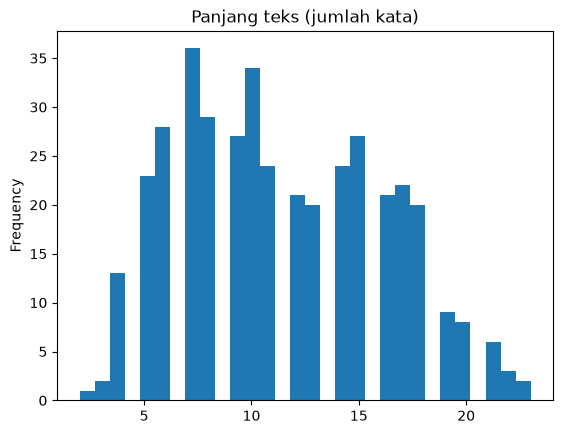

In [4]:
# [HAFALIN]
import matplotlib.pyplot as plt

df["jumlah_kata"] = df["corpus"].str.split().str.len()
print(df["jumlah_kata"].describe())

df["jumlah_kata"].plot(kind="hist", bins=30, title="Panjang teks (jumlah kata)")
plt.show()

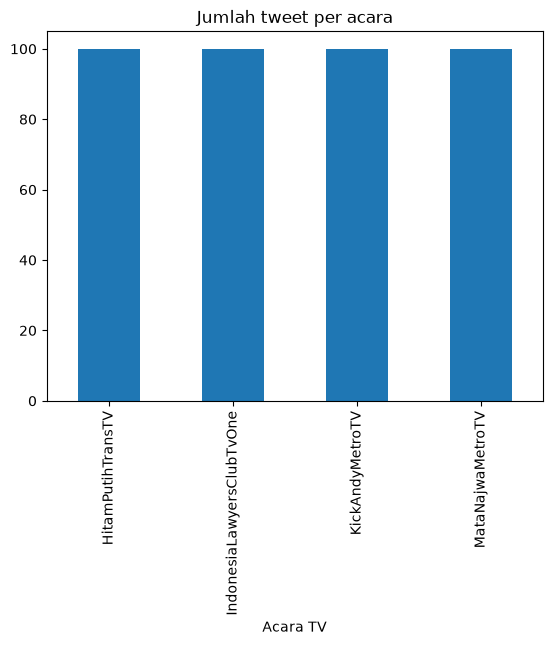

In [5]:
# [OPSIONAL] hapus kalau ga ada kolom kategori
df["Acara TV"].value_counts().plot(kind="bar", title="Jumlah tweet per acara")   # [GANTI] nama kolom kategori
plt.show()

## 3. Preprocessing (slide 8–16)

Slide 8: preprocessing = **Cleaning → Tokenization → Filtering → Stemming**.

- **Cleaning (slide 9–11)**: komputer nganggep "Hey" dan "hey" beda, dan simbol `- : , " +` ga ada maknanya. Jadi semua huruf dikecilin (`lower()`) dan simbol dibuang pakai regex `re.sub`.
- **Tokenization (slide 12–13)**: kalimat dipecah jadi daftar kata pakai `word_tokenize`. Ini konsep **Bag of Words** (slide 24).
- **Filtering / stopword (slide 15)**: buang kata umum yang ga bermakna ("yang", "di", "dan").
- **Stemming (slide 16)**: balikin ke kata dasar ("menangis" → "tangis") pakai **Sastrawi**. **Opsional**, karena lambat dan kadang salah. Di sini dimatikan.

Di PPT tiap langkah ditunjukin **terpisah** dan contohnya cuma 1 kalimat. Kode yang nyambungin semuanya jadi kolom `df['cleaned']` **ga ada** (slide 44 langsung loncat ke 45). Jadi yang perlu dihafal cuma "lem"-nya: `def preprocess(text):`, `return " ".join(...)`, dan `df['cleaned'] = df['corpus'].apply(preprocess)`. Isi fungsinya copas dari slide.

In [6]:
# slide 15: stopword
from nltk.corpus import stopwords
list_stopwords = set(stopwords.words('indonesian'))   # [GANTI] 'english' kalau datanya bahasa Inggris

# [HAFALIN] kata gaul yang ga ada di stopword NLTK, tambahin kalau nanti masih muncul di top keywords
list_stopwords.update(["yg", "ga", "gak", "aja", "banget", "dgn", "utk", "sm", "tp", "jd", "gue", "nya", "kalo", "tdk"])   # [GANTI]

# slide 16: stemming (Sastrawi)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

Fungsi di bawah: **isinya copas slide 11 → 13 → 15 → 16 berurutan**. Nama variabelnya dibiarin sama kayak di slide (`text`, `freq_tokens`, `tokens_without_stopword`, `list_tokens`) biar gampang dicocokin.

Satu baris tambahan buang link (`http...`): slide 9 bilang *remove links* tapi ga ngasih kodenya.

⚠️ `# [FIX]` **Regex slide 11 error kalau diketik persis**: di slide tertulis `{}-=`. Di dalam `[...]`, tanda `-` di antara dua karakter artinya **rentang** (kayak `a-z`), jadi `}-=` dibaca "dari `}` sampai `=`". Itu ga valid, keluarnya `error: bad character range }-=`. Solusinya kasih backslash: `{}\-=`. Cukup **tambah 1 karakter `\`**.

Kalau `word_tokenize` error `LookupError` (data NLTK belum ada) → jalanin `import nltk; nltk.download('punkt'); nltk.download('punkt_tab'); nltk.download('stopwords')`. Kalau ga ada internet → ganti `word_tokenize(text)` jadi `text.split()`.

In [7]:
import re
from nltk.tokenize import word_tokenize

def preprocess(text):                                                         # [HAFALIN]
    text = text.lower()                                                       # slide 11
    text = re.sub(r"http\S+", "", text)                                       # [HAFALIN] buang link
    text = re.sub(r"[-()\"#/@;:<>{}\-=~|.?,]", "", text)                      # slide 11 [FIX] slide: {}-= (error), jadi {}\-=
    freq_tokens = word_tokenize(text)                                         # slide 13
    tokens_without_stopword = [word for word in freq_tokens if not word in list_stopwords]   # slide 15
    # list_tokens = [stemmer.stem(token) for token in tokens_without_stopword]   # slide 16 [OPSIONAL] lambat
    return " ".join(tokens_without_stopword)                                   # [HAFALIN]

df['cleaned'] = df['corpus'].apply(preprocess)                                # [HAFALIN]
df[['corpus', 'cleaned']].head(10)

,corpus,cleaned
0,"Undang @N_ShaniJKT48 ke hitamputih, pemenang S...",undang n_shanijkt48 hitamputih pemenang ssk jk...
1,Selamat berbuka puasa Semoga amal ibadah hari ...,selamat berbuka puasa semoga amal ibadah ni di...
2,"Ada nih di trans7 hitam putih, dia dpt penghar...",nih trans7 hitam putih dpt penghargaan norwegi...
3,selamat ya mas @adietaufan masuk hitamputih,selamat ya mas adietaufan masuk hitamputih
4,Asiknya nonton Hitam Putih Trans7,asiknya nonton hitam putih trans7
5,@TRANS7 acara paling komplit dan menarik apala...,trans7 acara komplit menarik hitam putih
6,hitam putih T7 inspiratif banget,hitam putih t7 inspiratif
7,Suka banget dengan acara hitam putih,suka acara hitam putih
8,Keren lu bro #HitamPutihTrans7,keren lu bro hitamputihtrans7
9,"Tadi ada yg liat hitam putih di trans7 ga, Ada...",liat hitam putih trans7 sanggu ganteng


### Wordcloud (slide 19–21)

Slide 19: setelah preprocessing, bisa mulai **analisis deskriptif teks**: kata yang paling sering muncul divisualisasikan pakai **wordcloud**. Makin besar tulisannya, makin sering muncul.

Yang diubah dari slide 21:
- `twitter['id_cleaned']` → `df['cleaned']` (nama dataframe & kolom kita).
- `# [FIX]` `" ".join(val)` diganti `val`. Versi slide misahin **tiap huruf** pakai spasi ("halo" jadi "h a l o"), jadi wordcloud-nya isinya huruf doang.

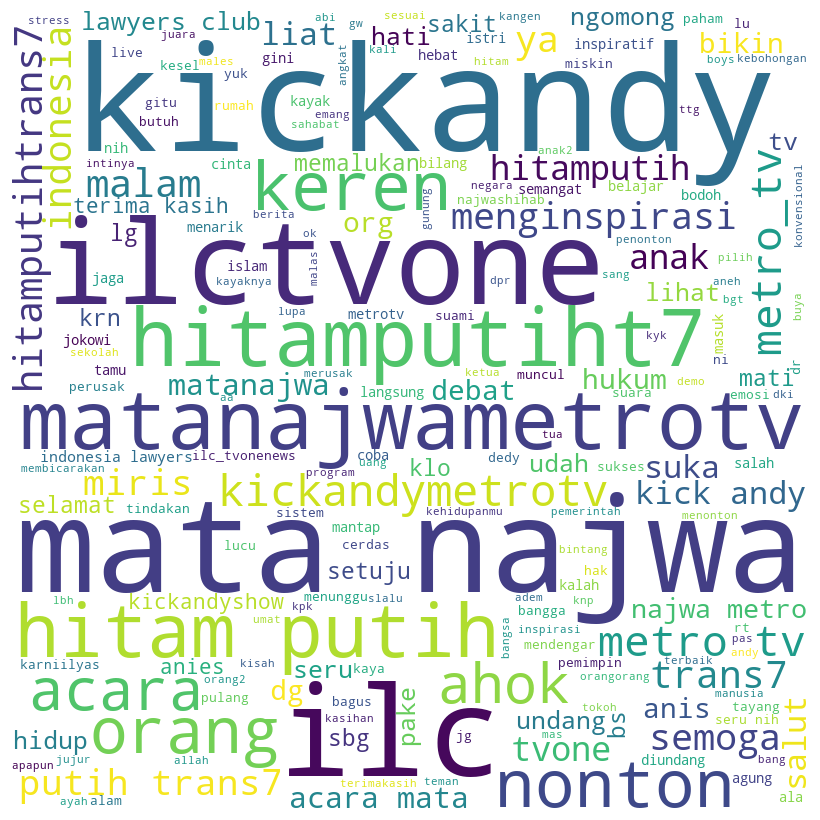

In [8]:
# slide 21
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

comment_words = ''

for val in df['cleaned']:          # slide: twitter['id_cleaned']
    val = str(val)

    comment_words += val + " "     # [FIX] slide: " ".join(val)+" "

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(comment_words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

## 4. TF-IDF: teks jadi angka (teori slide 22–35, kode slide 45)

KMeans cuma bisa ngitung **angka**, jadi tiap teks diubah jadi vektor pakai **TF-IDF**:
- **TF (slide 30)**: seberapa sering kata muncul di **satu dokumen**.
- **IDF (slide 32)**: `log(N / df)`. Kata yang muncul di **sedikit dokumen** bobotnya **besar** (khas), kata yang ada di **hampir semua dokumen** bobotnya **kecil** (umum).
- **TF-IDF = TF × IDF (slide 33)**: kata yang sering di dokumen itu tapi jarang di dokumen lain = kata **penting**.

Hasilnya matriks `X` ukuran **(jumlah dokumen × jumlah kata unik)**.

Parameter slide 45:
- `sublinear_tf=True`: TF pakai log, biar kata yang diulang-ulang ga terlalu dominan.
- `min_df=5`: kata yang muncul di **< 5 dokumen** dibuang (typo/langka). Kalau datanya kecil dan kolom `X` terlalu sedikit, turunin ke 2.
- `max_df=0.95`: kata yang muncul di **> 95% dokumen** dibuang (terlalu umum).

Kekurangan TF-IDF (slide 35): ga ngerti makna. "bagus" dan "keren" dianggap beda total.

**Yang diubah dari slide: ga ada.**

In [9]:
# slide 45
from sklearn.feature_extraction.text import TfidfVectorizer
# initialize the vectorizer
vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=5, max_df=0.95)
# fit_transform applies TF-IDF to clean texts - we save the array of vectors in X
X = vectorizer.fit_transform(df['cleaned'])

X.shape

(400, 86)

## 5. Tentukan k: Elbow + Silhouette `[HAFALIN]`

Di slide 46 dosen langsung pakai `n_clusters=3` **tanpa alasan**. Di ujian sebaiknya k dipilih pakai alasan, jadi coba k = 2 sampai 10:
- **Elbow (inertia)**: total jarak tiap titik ke centroid-nya. Pasti turun kalau k nambah. Cari **"siku"**, yaitu saat turunnya mulai landai.
- **Silhouette** (-1 s/d 1): seberapa cocok titik sama cluster-nya dibanding cluster lain. **Makin tinggi makin bagus.**

Polanya gampang dihafal: **loop k → fit KMeans → simpan inertia & silhouette → plot**.

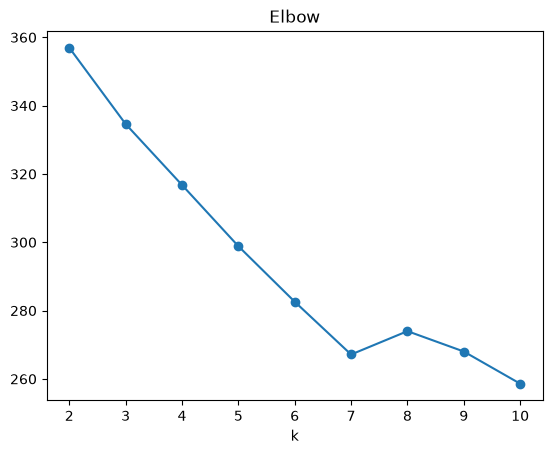

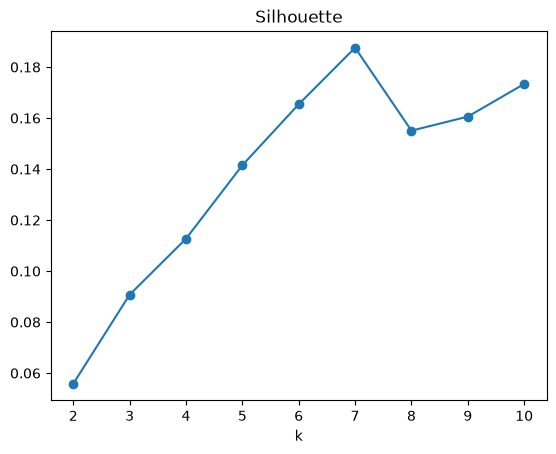

    k  inertia  silhouette
0   2  356.970       0.056
1   3  334.622       0.091
2   4  316.781       0.113
3   5  298.859       0.142
4   6  282.596       0.165
5   7  267.148       0.188
6   8  273.984       0.155
7   9  268.017       0.161
8  10  258.599       0.173


In [10]:
# [HAFALIN]
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

plt.plot(range(2, 11), inertia, "o-")
plt.title("Elbow"); plt.xlabel("k"); plt.show()

plt.plot(range(2, 11), sil, "o-")
plt.title("Silhouette"); plt.xlabel("k"); plt.show()

print(pd.DataFrame({"k": range(2, 11), "inertia": inertia, "silhouette": sil}).round(3))

**Cara baca grafik di atas** (**[GANTI]** narasi ini sesuai grafik datamu):

- **Elbow**: inertia turun pelan dan rata (±18–22 tiap nambah 1 k), jadi **ga ada siku yang jelas**.
- **Silhouette**: naik dari 0.056 (k=2) → 0.091 (k=3) → **0.113 (k=4)** → terus naik pelan sampai puncak 0.188 di k=7. Semua nilainya kecil (< 0.2). Ini **wajar untuk teks pendek** kayak tweet (±11 kata): vektor TF-IDF-nya banyak nol, jadi jarak antar dokumen mirip-mirip.
- k=7 memang silhouette tertinggi, tapi cluster-nya jadi kecil-kecil dan susah diinterpretasi, sedangkan bedanya cuma ±0.07.

**Dipilih k = 4**, karena silhouette naik jelas sampai k=4, dan datanya memang tentang 4 acara TV, jadi mudah diinterpretasi dan dicocokkan.

> Kalau di ujian ga tau ada berapa kategori: pilih k di **siku elbow** atau **silhouette tertinggi**, terus tulis alasannya kayak di atas.

## 6. KMeans (teori slide 39–40, kode slide 46)

Cara kerja KMeans (slide 40):
1. Taruh **k centroid** secara acak.
2. Tiap dokumen masuk ke cluster dengan centroid **terdekat**.
3. Centroid dipindah ke **rata-rata** anggota cluster-nya.
4. Ulangi 2–3 sampai centroid ga pindah lagi.

Slide 39: teks yang udah jadi vektor TF-IDF, kalau mirip posisinya **berdekatan**, jadi bisa dikelompokkan KMeans.

Alternatif di PPT: **DBSCAN** (slide 41–42), ga perlu nentuin k, tapi harus tuning `eps` & `min_samples`. Buat teks susah dituning, jadi pakai KMeans.

**Yang diubah dari slide: cuma `n_clusters=3` → k hasil section 5.**

In [11]:
# slide 46
from sklearn.cluster import KMeans

# initialize kmeans with 3 centroids
kmeans = KMeans(n_clusters=4, random_state=42)   # [GANTI] slide: n_clusters=3
# fit the model
kmeans.fit(X)
# store cluster labels in a variable
clusters = kmeans.labels_

### Evaluasi `[HAFALIN]`

Soal minta **koefisien cluster**, PPT ga ada. Cukup 2 skor:
- **Silhouette**: -1 s/d 1, **makin dekat 1 makin bagus**. Sekitar 0 = cluster saling tumpang tindih.
- **Davies-Bouldin**: ≥ 0, **makin kecil makin bagus**.

Teks pendek (tweet) silhouette-nya kecil (< 0.2) itu **normal**. Tulis apa adanya dan jelasin di kesimpulan.

In [12]:
# [HAFALIN]
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette    :", silhouette_score(X, clusters))
print("Davies-Bouldin:", davies_bouldin_score(X.toarray(), clusters))

Silhouette    : 0.11268726468480059
Davies-Bouldin: 2.679814494963992


## 7. Visualisasi pakai PCA (teori slide 47, kode slide 48, 49, 51)

Slide 47: `X` dimensinya ratusan/ribuan (1 kolom per kata), **ga mungkin di-plot**. Jadi pakai **PCA** buat "memipihkan" jadi **2 dimensi** (`x0`, `x1`), terus di-scatter diwarnai per cluster.

Cara baca: warna yang **ngumpul & terpisah** = cluster jelas. Warna yang **numpuk** = cluster mirip satu sama lain. PCA 2D cuma "bayangan", jadi wajar ada yang numpuk.

**Yang diubah dari slide: cuma judul plot di slide 51.**

In [13]:
# slide 48
from sklearn.decomposition import PCA

# initialize PCA with 2 components
pca = PCA(n_components=2, random_state=42)
# pass our X to the pca and store the reduced vectors into pca_vecs
pca_vecs = pca.fit_transform(X.toarray())
# save our two dimensions into x0 and x1
x0 = pca_vecs[:, 0]
x1 = pca_vecs[:, 1]

In [14]:
# slide 49
# assign clusters and pca vectors to our dataframe
df['cluster'] = clusters
df['x0'] = x0
df['x1'] = x1

df[['corpus', 'cleaned', 'cluster', 'x0', 'x1']]

,corpus,cleaned,cluster,x0,x1
0,"Undang @N_ShaniJKT48 ke hitamputih, pemenang S...",undang n_shanijkt48 hitamputih pemenang ssk jk...,2,-0.027581,-0.030858
1,Selamat berbuka puasa Semoga amal ibadah hari ...,selamat berbuka puasa semoga amal ibadah ni di...,2,-0.035144,-0.028033
2,"Ada nih di trans7 hitam putih, dia dpt penghar...",nih trans7 hitam putih dpt penghargaan norwegi...,2,-0.090226,-0.119805
3,selamat ya mas @adietaufan masuk hitamputih,selamat ya mas adietaufan masuk hitamputih,2,-0.025779,-0.036087
4,Asiknya nonton Hitam Putih Trans7,asiknya nonton hitam putih trans7,2,-0.101652,-0.127023
...,...,...,...,...,...
395,ini apa banget deh gw paling kesel klo orang2 ...,deh gw kesel klo orang2 debat pake emosi gini ...,2,-0.080619,-0.171602
396,Orang miskin semakin miskin klo sekolah melaku...,orang miskin miskin klo sekolah pungutan liar,2,0.016647,-0.050878
397,"ga boLeh emosi, cepat tua, nonton #matanajwame...",emosi cepat tua nonton matanajwametrotv lihat ...,2,-0.090551,-0.205390
398,dr penampilan saja kyk preman taunya bkin kisr...,dr penampilan kyk preman taunya bkin kisruh pe...,2,-0.148602,-0.422005


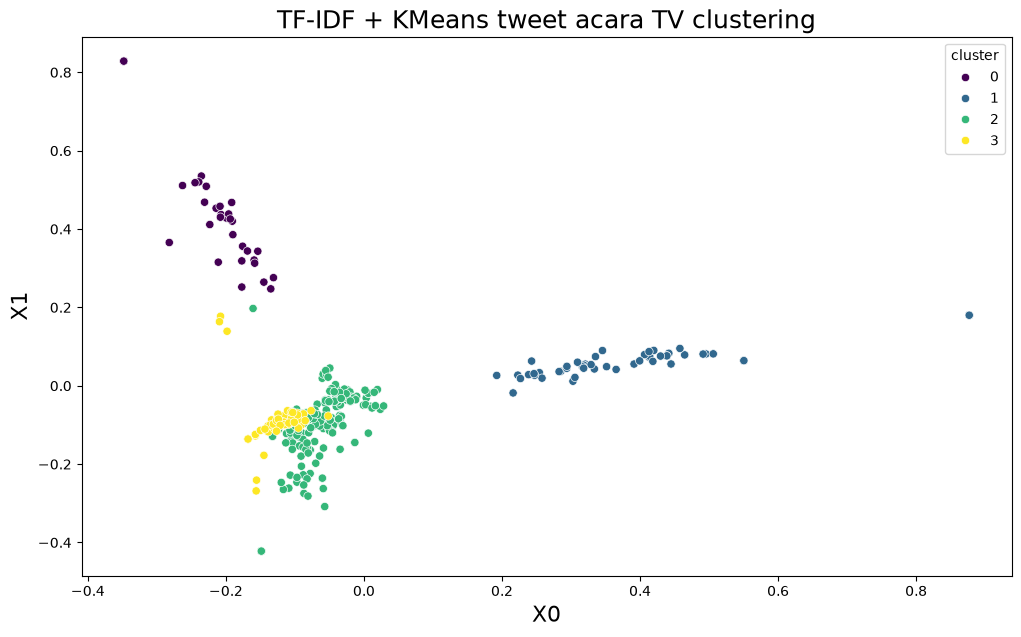

In [15]:
# slide 51
import seaborn as sns

# set image size
plt.figure(figsize=(12, 7))
# set a title
plt.title("TF-IDF + KMeans tweet acara TV clustering", fontdict={"fontsize": 18})   # [GANTI] slide: 20newsgroup
# set axes names
plt.xlabel("X0", fontdict={"fontsize": 16})
plt.ylabel("X1", fontdict={"fontsize": 16})
# create scatter plot with seaborn, where hue is the class used to group the data
sns.scatterplot(data=df, x='x0', y='x1', hue='cluster', palette="viridis")
plt.show()

## 8. Insight tiap cluster

Bagian terpenting buat nilai: **tiap cluster isinya tentang apa?** Dilihat dari:
1. **Top keywords** (slide 50)
2. **Wordcloud per cluster** (slide 21 diulang per cluster)
3. **Contoh teks asli** per cluster `[HAFALIN]`
4. **Crosstab ke label asli** kalau ada `[HAFALIN]`

### Top keywords (slide 50)

Yang diubah dari slide:
- `# [FIX]` di slide tertulis `ef get_top_keywords`, harusnya **`def`**.
- Selebihnya sama persis. Variabel `df` di dalam fungsi itu **lokal** (cuma hidup di dalam fungsi), jadi ga ngerusak `df` utama.

Cara baca output: urutannya dari kiri ke kanan **makin penting**, jadi **kata paling kanan = paling dominan**.

In [16]:
# slide 50
import numpy as np

def get_top_keywords(n_terms):      # [FIX] slide: "ef"
    """This function returns the keywords for each centroid of the KMeans"""
    df = pd.DataFrame(X.todense()).groupby(clusters).mean() # groups the TF-IDF vector by cluster

    terms = vectorizer.get_feature_names_out() # access tf-idf terms
    for i,r in df.iterrows():
        print('\nCluster {}'.format(i))
        print(','.join([terms[t] for t in np.argsort(r)[-n_terms:]])) # for each row of the dataframe, find the n terms that have the highest tf idf score

get_top_keywords(10)


Cluster 0
keren,malam,acara,setuju,hebat,bikin,hati,indonesia,tvone,ilc

Cluster 1
hidup,nonton,miris,mati,agung,kickandyshow,ahok,orang,menginspirasi,kickandy

Cluster 2
keren,hitamputihtrans7,orang,kickandymetrotv,trans7,hitam,putih,hitamputiht7,matanajwametrotv,ilctvone

Cluster 3
debat,nonton,anies,keren,acara,metro_tv,metro,tv,mata,najwa


### Wordcloud per cluster (slide 21 diulang)

Kode slide 21 yang sama, bedanya cuma loop-nya ngambil data **satu cluster aja**: `df[df['cluster'] == c]['cleaned']`.

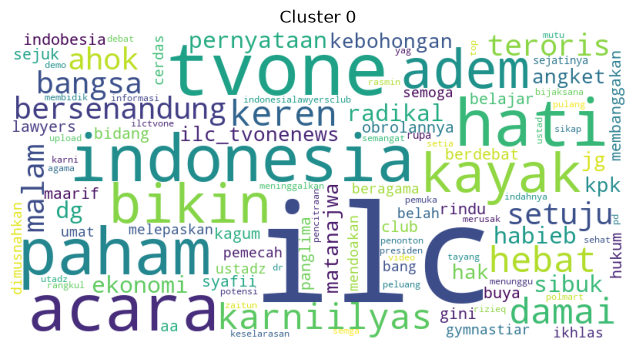

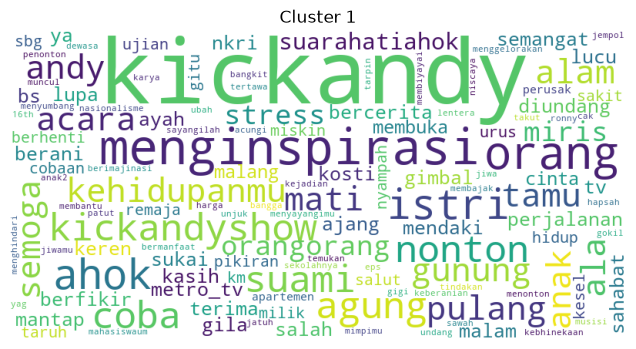

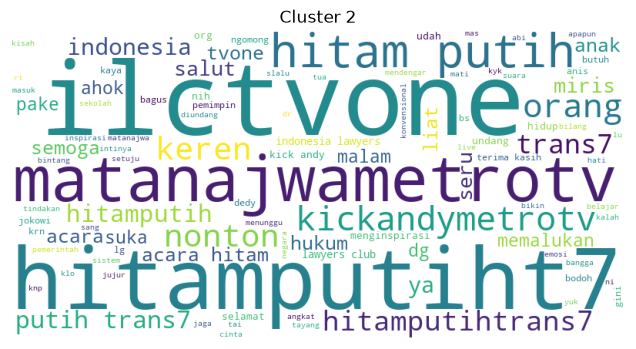

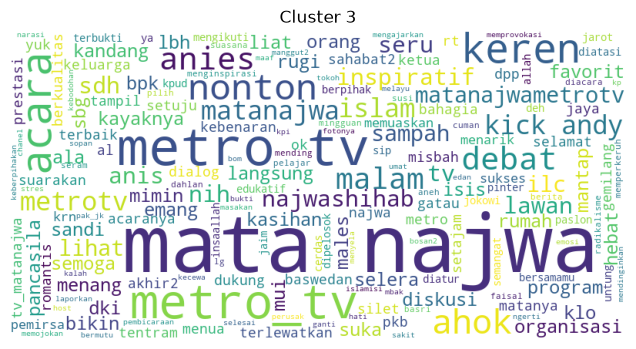

In [17]:
# slide 21, diulang per cluster
for c in range(4):                                  # [GANTI] 4 = jumlah cluster
    comment_words = ''
    for val in df[df['cluster'] == c]['cleaned']:   # cuma ambil data cluster c
        val = str(val)
        comment_words += val + " "

    wordcloud = WordCloud(width = 800, height = 400,
                    background_color ='white',
                    min_font_size = 10).generate(comment_words)

    plt.figure(figsize = (8, 4))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"Cluster {c}")
    plt.show()

In [18]:
# [HAFALIN] contoh teks asli + jumlah data tiap cluster
print(df['cluster'].value_counts())

for c in range(4):                       # [GANTI] 4 = jumlah cluster
    print(f"\n===== Cluster {c} =====")
    for t in df[df['cluster'] == c]['corpus'].head(5):
        print("-", t)

cluster
2    227
1     70
3     57
0     46
Name: count, dtype: int64

===== Cluster 0 =====
- RINDU ILC INDOBESIA LAWYERS CLUB DI TVONE
- Selalu kagum dengan Buya Syafii Maarif - ILC tvOne https://youtu.be/gPXSkLtAL5Y
- Saya punya Panglima yang membanggakan, ILC tvOne https://youtu.be/tR2tN1u7eAw
- Sejuk kalo ILC itu kayak gini obrolannya - ILC tvOne
- Belajar cara berdebat di bidang hukum #ilc

===== Cluster 1 =====
- Kickandy gokil #kickandy
- Terima kasih sudah menonton acara #kickandy eps ubah mimpimu jadi tindakan, semoga bermanfaat
- Temukan lentera jiwamu #kickandy #mahasiswaum
- Agung.. Saya akan undang lagi.. Untuk bercerita banyak tentang perjalanan kehidupanmu.. #KickAndy
- PARA MUSISI YG MENGGELORAKAN SEMANGAT NASIONALISME DAN KEBHINEKAAN UNJUK GIGI #KICKANDY NKRI HARGA MATI...

===== Cluster 2 =====
- Undang @N_ShaniJKT48 ke hitamputih, pemenang SSK JKT48 harusnya mJKT48 ini lebih Layak di Undang karena prestasinya
- Selamat berbuka puasa Semoga amal ibadah hari ni diteri

### Cek ke label asli `[HAFALIN]` `[OPSIONAL]`

Kalau dataset punya kolom kategori, pakai **crosstab** (tabel silang cluster × label). Kalau satu cluster didominasi satu label, berarti cluster-nya "bener". Label ini **ga dipakai** waktu clustering, cuma buat ngecek.

In [19]:
# [HAFALIN] [OPSIONAL] hapus kalau ga ada kolom label
pd.crosstab(df['cluster'], df['Acara TV'])   # [GANTI] nama kolom label

Acara TV,HitamPutihTransTV,IndonesiaLawyersClubTvOne,KickAndyMetroTV,MataNajwaMetroTV
cluster,,,,
0,0,46,0,0
1,0,0,70,0
2,100,54,30,43
3,0,0,0,57


In [20]:
# [HAFALIN] [OPSIONAL]
pd.crosstab(df['cluster'], df['Sentiment'])   # [GANTI] nama kolom label

Sentiment,negative,positive
cluster,,
0,26,20
1,28,42
2,117,110
3,29,28


### Kasih nama cluster (slide 50 kanan) + plot ulang (slide 51)

Setelah liat top keywords, wordcloud, contoh teks & crosstab, kasih **nama** ke tiap cluster, terus plot ulang biar legend-nya kebaca (kayak plot di slide 52).

⚠️ Jalanin **paling akhir**. Setelah ini kolom `cluster` berubah dari angka jadi teks, jadi cell di atas yang pakai `df['cluster'] == c` ga bisa dijalanin ulang (kecuali jalanin ulang dari slide 49).

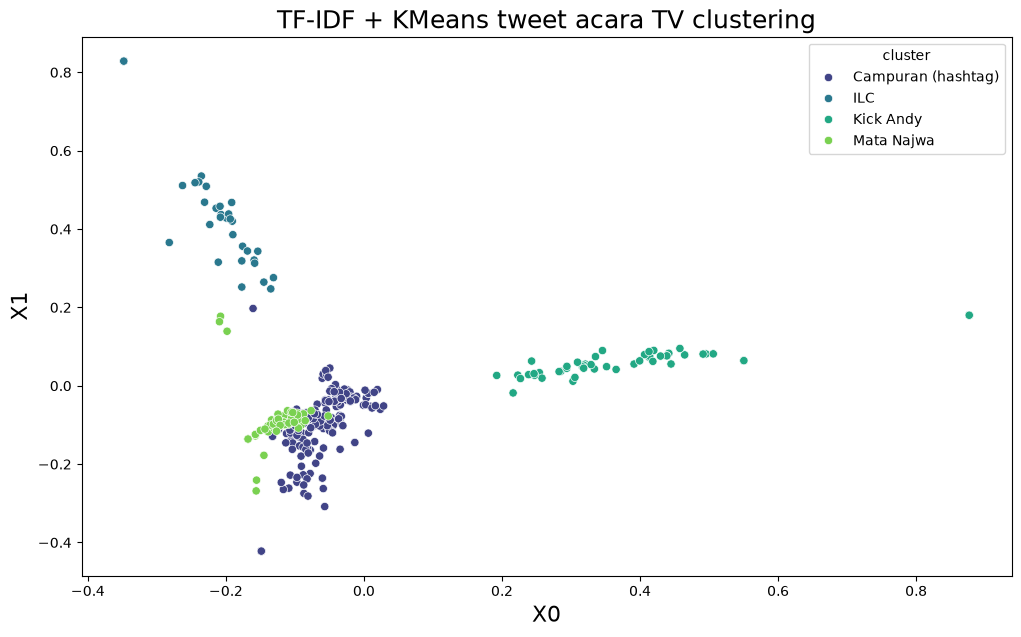

In [21]:
# slide 50 (kanan)
# map clusters to appropriate labels
cluster_map = {0: "ILC", 1: "Kick Andy", 2: "Campuran (hashtag)", 3: "Mata Najwa"}   # [GANTI] isi sesuai top keywords datamu
# apply mapping
df['cluster'] = df['cluster'].map(cluster_map)

# slide 51
plt.figure(figsize=(12, 7))
plt.title("TF-IDF + KMeans tweet acara TV clustering", fontdict={"fontsize": 18})   # [GANTI]
plt.xlabel("X0", fontdict={"fontsize": 16})
plt.ylabel("X1", fontdict={"fontsize": 16})
sns.scatterplot(data=df, x='x0', y='x1', hue='cluster', palette="viridis")
plt.show()

## 9. Kesimpulan

**[GANTI] seluruh isi section ini sesuai output datamu.** Polanya per cluster: **jumlah data → kata dominan → isinya tentang apa → dicocokkan ke label (kalau ada)**.

### Evaluasi
- **Silhouette = 0.113**, **Davies-Bouldin = 2.68** → secara matematis cluster-nya masih **lemah / tumpang tindih**. Wajar untuk tweet pendek, karena banyak kata umum (acara, nonton, keren, orang) muncul di semua topik.
- Di plot PCA, cluster ILC, Kick Andy, dan Mata Najwa "menjulur" ke arah masing-masing, sedangkan cluster campuran numpuk di tengah.

### Insight tiap cluster
- **Cluster 0: ILC (n = 46)**. Kata dominan: *ilc, tvone, indonesia, hati, hebat, setuju*. **100% tweet ILC**. Isinya komentar soal **debat hukum/politik** di ILC (kagum sama narasumber, "belajar cara berdebat"). Sentimen sedikit **negatif** (26 vs 20).
- **Cluster 1: Kick Andy (n = 70)**. Kata dominan: *kickandy, menginspirasi, orang, ahok, agung, mati, miris*. **100% tweet Kick Andy**. Isinya tentang **kisah inspiratif** narasumber, sentimen cenderung **positif** (42 vs 28).
- **Cluster 2: Campuran / hashtag (n = 227)**. Kata dominan: *ilctvone, matanajwametrotv, hitamputiht7, hitam, putih, kickandymetrotv*. Isinya tweet yang menyebut acara **cuma lewat hashtag gabungan** (mis. `#HitamPutihTrans7`, `#ILCTvOne`), jadi yang kebaca model nama hashtag-nya, bukan isi obrolan. **Semua tweet Hitam Putih (100)** masuk sini, ditambah 54 ILC, 30 Kick Andy, 43 Mata Najwa. Ini cluster **paling ga bersih**, sentimennya berimbang (117 vs 110).
- **Cluster 3: Mata Najwa (n = 57)**. Kata dominan: *najwa, mata, metro, tv, anies, debat*. **100% tweet Mata Najwa**. Isinya obrolan **politik/debat** dengan tokoh (Anies), sentimen berimbang (29 vs 28).

### Ringkasan
TF-IDF + KMeans berhasil memisahkan **3 dari 4 acara** dengan **purity 100%** (ILC, Kick Andy, Mata Najwa). Kelemahannya ada di **cluster 2**, penyebabnya **preprocessing**: hashtag gabungan kayak `hitamputiht7` dan `ilctvone` dianggap satu kata unik yang beda dari "hitam putih" atau "ilc". Perbaikan yang bisa dicoba:
1. pecah / normalisasi hashtag (mis. `ilctvone` → `ilc`),
2. buang nama acara dari teks, biar cluster terbentuk dari **isi** tweet,
3. coba stemming (slide 16) atau DBSCAN (slide 41).